In [15]:
import random
import json

import numpy as np
import matplotlib.pyplot as plt

# import matplotlib.colors as mcolors
import pandas as pd
import seaborn as sns

import jit

plt.style.use("../plotStyle.mplstyle")
random.seed(123456)

vgc_predictions = pd.read_csv("vgc_predictions.csv")
vgc_predictions["probeobs"] = vgc_predictions.obstacle.str.replace("obs-", "").astype(int)
vgc_predictions["grid"] = vgc_predictions.grid.str.replace("grid-", "").astype(int)
vgc_predictions.drop(columns=["obstacle"], inplace=True)
vgc_predictions.head()


with open("data/memorytrials.json") as f:
    mem = json.load(f)
mem = pd.DataFrame(mem)
mem["correct_binary"] = mem.correct.astype(int)
mem.head()


with open("data/attentiontrials-exp1.json") as f:
    attn = json.load(f)
attn = pd.DataFrame(attn)
attn.head()

with open("data/attentiontrials-exp2.json") as f:
    attn2 = json.load(f)
attn2 = pd.DataFrame(attn2)

with open("data/attentiontrials-critical.json") as f:
    attn_critical = json.load(f)
attn_critical = pd.DataFrame(attn_critical)

with open("data/hovering-data-trials.json") as f:
    hover1 = json.load(f)
hover1 = pd.DataFrame(hover1)
hover1["grid"] = hover1.grid.astype(str).str[:-2]
hover1["grid"] = hover1.grid.str.replace("grid-", "").astype(int)
hover1["probeobs"] = hover1.obstacle.astype(int)

with open("data/hovering-data-trials-2.json") as f:
    hover2 = json.load(f)
hover2 = pd.DataFrame(hover2)
hover2["grid"] = hover2.grid.str.replace("grid-", "").astype(int)
hover2["probeobs"] = hover2.obstacle.astype(int)


with open("data/mazes_0-11.json") as f:
    init_maze = json.load(f)

    init_maze = {k[:-2]: v for k, v in init_maze.items()}

with open("data/mazes_12-15.json") as f:
    memory_maze = json.load(f)

maze = {**init_maze, **memory_maze}
dvs = {
    "initial_awareness": (attn, "response"),
    "upfront_awareness": (attn2, "response"),
    "critical_memory": (mem, "correct"),
    "critical_confidence": (mem, "response_conf"),
    "critical_awareness": (attn_critical, "response"),
    "initial_hover": (hover1, "hovered"),
    "initial_loghover_duration": (hover1, "log_hoverduration"),
    "critical_hover": (hover2, "hovered"),
    "critical_loghover_duration": (hover2, "log_hoverduration"),
}


def get_jit_predictions(measures):
    out = []
    # for dv, (data, colname) in dvs.items():
    for dv in measures:
        data, colname = dvs[dv]
        fit_results = pd.read_csv(f"output/decay_astar_straight_fixed/fit-{dv}.csv")

        best_pars = fit_results.iloc[fit_results["r2"].idxmax()]

        try:
            noise_floor = best_pars["noise_floor"]
        except KeyError:
            noise_floor = 0.00

        pars = jit.AStarPars(
            best_pars["alpha_d"], best_pars["alpha_h"], best_pars["decay"], noise_floor
        )
        model_pred = jit.AStarRolloutStraight.predict(pars, data.grid.unique(), 300)
        # model_pred = jit.AStarRollout.predict(
        #     pars,
        #     data.grid.unique(),
        #     300
        # )
        model_pred["dv"] = dv
        model_pred["params"] = str(pars)
        # model_pred["prob"] = np.clip(model_pred.prob, 0.1, 1.0)
        print(model_pred.head())
        out.append(model_pred)
    model_preds = pd.concat(out, ignore_index=True)
    return model_preds


# jit_predictions = get_jit_predictions(["critical_memory", "initial_hover", "critical_hover"])
# jit_predictions = get_jit_predictions(dvs.keys())
# get_jit_predictions(dvs.keys()).to_csv("jit_predictions.csv", index=False)
jit_predictions = pd.read_csv("jit_predictions.csv")
# jit_predictions = get_jit_predictions(dvs.keys())

In [16]:
# memory_bootstrap = pd.read_csv("./output/jit_bootstrap_critical_memory.csv")
# memory_bootstrap_ci = (
#     memory_bootstrap.groupby(["grid", "probeobs"])
#     .prob.agg(lambda x: 0.5 * (np.quantile(x, 0.975) - np.quantile(x, 0.025)))
#     # .prob.agg(lambda x: x.std())
#     .reset_index()
#     .rename(columns={"prob": "model_p_ci"})
# )

# hover_bootstrap = pd.read_csv("./output/jit_bootstrap_critical_hover.csv")
# hover_bootstrap_ci = (
#     hover_bootstrap.groupby(["grid", "probeobs"])
#     .prob.agg(lambda x: 0.5 * (np.quantile(x, 0.975) - np.quantile(x, 0.025)))
#     # .prob.agg(lambda x: x.std())
#     .reset_index()
#     .rename(columns={"prob": "model_p_ci"})
# )
# memory_bootstrap_ci

In [17]:
def partial_correlation(x, y, z):
    """Compute the partial correlation between x and y, controlling for z."""
    fit1 = np.polyfit(z, x, 1)
    fit2 = np.polyfit(z, y, 1)

    x_residual = x - fit1[0] * z - fit1[1]
    y_residual = y - fit2[0] * z - fit2[1]

    return np.corrcoef(x_residual, y_residual)[0, 1]


def semipartial_correlation(x, y, z):
    fit1 = np.polyfit(z, x, 1)

    x_residual = x - fit1[0] * z - fit1[1]
    # y_residual = y - fit2[0] * z - fit2[1]

    return np.corrcoef(x_residual, y)[0, 1]


def viz(
    joint_data,
    colname,
    title,
    ax: plt.Axes = None,
    one_to_one=False,
    rmse=False,
    manual_legend=True,
    errorbars=False,
):
    if not ax:
        fig, ax = plt.subplots(figsize=(4, 4))
    joint_data.pipe(
        # (ax.scatter, "data"), x="prob", y=colname, fc="tab:blue", ec="k", lw=3, s=100, alpha=0.7
        # (ax.scatter, "data"), x="prob", y=colname, fc="#335c67", ec="k", lw=1, s=60, alpha=0.7
        # (ax.scatter, "data"), x="prob", y=colname, fc="tab:gray", ec="k", lw=1, s=40, alpha=0.7
        (ax.errorbar, "data"),
        x="prob",
        y=colname,
        # xerr="model_p_ci" if errorbars else None,
        yerr=f"{colname}_ci" if errorbars else None,
        fmt="o",
        ms=np.sqrt(40),
        alpha=0.7,
        capsize=5,
        color="tab:gray",
        lw=1,
        markeredgecolor="k",
    )
    ax.set_xlabel("model")
    ax.set_ylabel("Human")

    b, a = np.polyfit(joint_data.prob, joint_data[colname], 1)
    xlims = ax.get_xlim()

    if colname == "correct":
        lims = (0.5 - 0.1, 1.05)
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        if one_to_one:
            ax.axline((lims[0], lims[0]), (lims[1], lims[1]), ls="--", c="tab:blue")
    elif colname == "hovered":
        ax.set_xlim((-0.05, 1.05))
        ax.set_ylim((-0.05, 1.05))
        if one_to_one:
            ax.axline((0, 0), (1, 1), ls="--", c="tab:blue")
    ax.axline((xlims[0], a + b * xlims[0]), (xlims[1], a + b * xlims[1]), ls="--", c="gray")
    ax.set_title(title)
    if not manual_legend:
        string = f"$r$={(joint_data.prob.corr(joint_data[colname])):.2f}" + (
            "\nRMSE={np.sqrt(((joint_data.prob - joint_data[colname]) ** 2).mean()):.2f}"
            if rmse
            else ""
        )
        ax.legend(
            [],
            [],
            title=string,
            loc="lower right",
            frameon=False,
            title_fontproperties={"size": 18, "weight": "bold"},
        )
    else:
        if rmse:
            plt.text(
                0.05,
                0.9,
                f"$r$={(joint_data.prob.corr(joint_data[colname])):.2f}\nRMSE={np.sqrt(((joint_data.prob - joint_data[colname]) ** 2).mean()):.2f}",
            )
            # ax.legend([], [], title=f"$r$={(joint_data.prob.corr(joint_data[colname])):.2f}\nRMSE={np.sqrt(((joint_data.prob - joint_data[colname]) ** 2).mean()):.2f}", loc="lower right")
        else:
            xpos = 0.8 if colname == "correct" else 0.6
            ypos = 0.425 if colname == "correct" else 0.00
            plt.text(
                xpos,
                ypos,
                f"$r$={(joint_data.prob.corr(joint_data[colname])):.2f}",
                fontsize=18,
                fontweight="bold",
            )
        # ax.legend([], [], title=f"$r$={(joint_data.prob.corr(joint_data[colname])):.2f}", loc="lower right")
    # ax.legend([], [], title=f"R={(avg_rank_corr(joint_data, 'prob', colname)):.2f}")
    return ax


def avg_rank_corr(df, c1, c2):
    from scipy.stats import spearmanr

    return df.groupby("grid").apply(lambda x: spearmanr(x[c1], x[c2])[0]).mean()

critical_memory
AStarPars(alpha_d=0.2105263157894736, alpha_h=0.0526315789473683, decay=0.3885739518570975, noise_floor=0.0, debug=False)
rmse: 0.08255606094299375
initial_hover
AStarPars(alpha_d=0.2105263157894736, alpha_h=-0.4736842105263158, decay=0.0, noise_floor=0.0, debug=False)
rmse: 0.18444641238030243
critical_hover
AStarPars(alpha_d=1.263157894736842, alpha_h=-0.736842105263158, decay=0.0, noise_floor=0.0, debug=False)
rmse: 0.13595693229051312
rmse: 0.10368733006526983
rmse: 0.39777761458692273
rmse: 0.28708549783815057


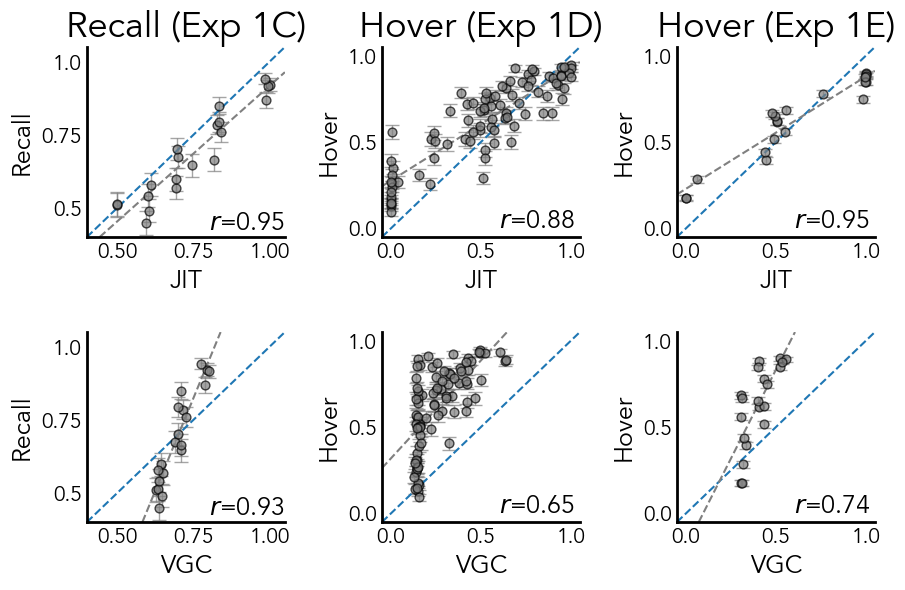

In [18]:
fig = plt.figure(figsize=(9, 6))
# jit_preds = {}
i = 1
_dvs = {
    dv: data
    for dv, data in dvs.items()
    if dv in ["critical_memory", "initial_hover", "critical_hover"]
}
titles = ["Recall (Exp 1C)", "Hover (Exp 1D)", "Hover (Exp 1E)"]
with plt.rc_context({"axes.labelsize": 18}):
    for dv, (data, colname) in _dvs.items():
        ax = fig.add_subplot(2, 3, i)
        print(dv)
        print(jit_predictions.loc[jit_predictions.dv == dv, "params"].iloc[0])

        joint_pred = jit.AStarRollout.combine(
            data.groupby(["grid", "probeobs"])[colname]
            .agg(["mean", "sem"])
            .reset_index()
            .rename(columns={"mean": colname, "sem": f"{colname}_ci"}),
            jit_predictions.loc[jit_predictions.dv == dv],
        )
        # joint_pred = pd.merge(joint_pred, hover_bootstrap_ci if dv != "critical_memory" else memory_bootstrap_ci, on=["grid", "probeobs"], how="left")
        if dv == "critical_memory":
            joint_pred["prob"] = joint_pred.prob / 2 + 0.5
        viz(
            joint_pred,
            colname,
            title=titles[i - 1],
            ax=ax,
            one_to_one=True,
            rmse=False,
            errorbars=True,
        )
        print("rmse:", np.sqrt(((joint_pred.prob - joint_pred[colname]) ** 2).mean()))
        if dv == "critical_memory":
            plt.yticks([0.5, 0.75, 1.0], [0.5, 0.75, 1.0])
        ax.set_xlabel("JIT")
        # if i != 1:
        # ax.set_ylabel("")
        ax.set_ylabel(titles[i - 1].split(" ")[0])

        i += 1

    for dv, (data, colname) in _dvs.items():
        ax = fig.add_subplot(2, 3, i)
        vgc_joint_pred = pd.merge(
            vgc_predictions.loc[vgc_predictions.dv == dv],
            data.groupby(["grid", "probeobs"])[colname]
            .agg(["mean", "sem"])
            .reset_index()
            .rename(columns={"mean": colname, "sem": f"{colname}_ci"}),
            on=["grid", "probeobs"],
        )
        vgc_joint_pred["prob"] = vgc_joint_pred.dynamic_vgc
        vgc_joint_pred["model_p_ci"] = 0.0
        if dv == "critical_memory":
            vgc_joint_pred["prob"] = vgc_joint_pred.prob / 2 + 0.5
        viz(
            vgc_joint_pred,
            colname,
            title=f"VGC {dv.replace('_', ' ')}",
            ax=ax,
            one_to_one=True,
            rmse=False,
            errorbars=True,
        )
        if dv == "critical_memory":
            plt.yticks([0.5, 0.75, 1.0], [0.5, 0.75, 1.0])
        ax.set_title("")
        ax.set_xlabel("VGC")
        ax.set_ylabel(titles[i - 4].split(" ")[0])

        print("rmse:", np.sqrt(((vgc_joint_pred.prob - vgc_joint_pred[colname]) ** 2).mean()))

        # if i != 4:
        #     ax.set_ylabel("")
        i += 1

    fig.tight_layout()
    fig.subplots_adjust(hspace=0.5)
    fig.savefig("../figures/jit_navigation_threeplots.pdf", bbox_inches="tight")

initial_awareness Awareness (1A) response 0
upfront_awareness Awareness (1B) response 1
critical_memory Recall (1C) correct 2
critical_confidence Confidence (1C) response_conf 3
critical_awareness Awareness (1C) response 4
initial_hover Hover (1D) hovered 5
initial_loghover_duration Hover Duration (1D) log_hoverduration 6
critical_hover Hover (1E) hovered 7
critical_loghover_duration Hover Duration (1E) log_hoverduration 8


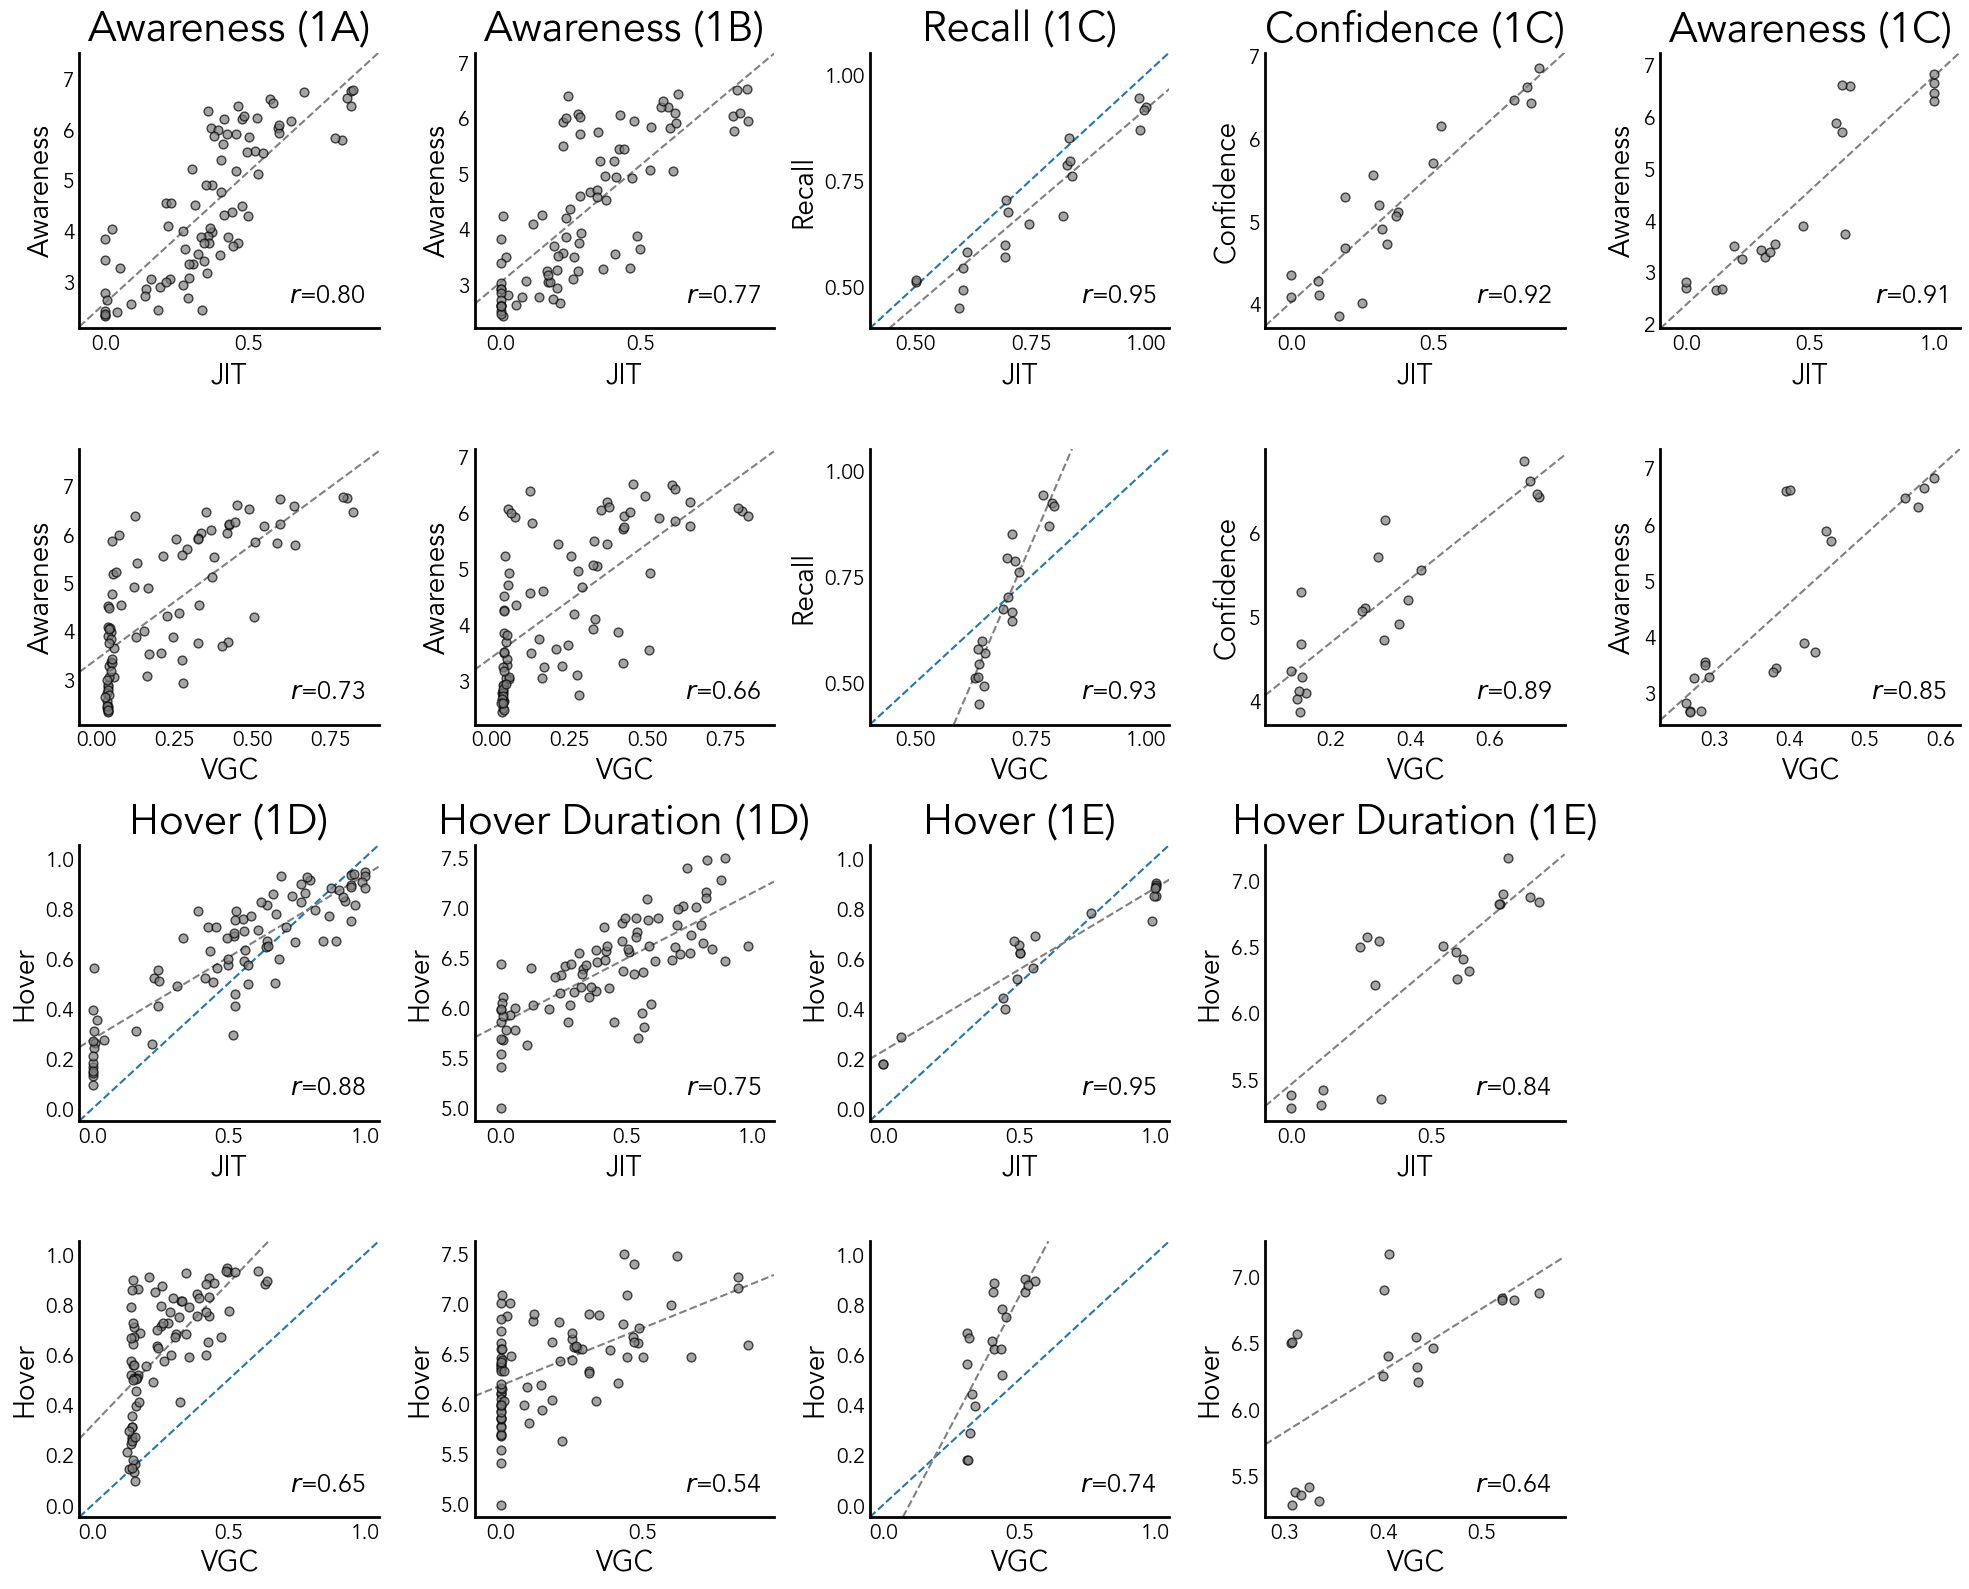

In [19]:
rows, cols = 4, 5
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
i = 0
jit_rows = iter([0, 2])
vgc_rows = iter([1, 3])
# _dvs = {dv: data for dv, data in dvs.items() if dv in ["critical_memory", "initial_hover", "critical_hover"]}
titles = ["Awareness (1A)", "Awareness (1B)", "Recall (1C)", "Confidence (1C)", "Awareness (1C)", "Hover (1D)", "Hover Duration (1D)", "Hover (1E)", "Hover Duration (1E)"]
with plt.rc_context({'axes.labelsize': 18, "axes.titlesize": 30}):
    row = next(jit_rows)
    for dv, (data, colname) in dvs.items():
        ax = axes[row, i % cols]
        print(dv, titles[i], colname, i)
        # print(jit_predictions.loc[jit_predictions.dv == dv, "params"].iloc[0])

        joint_pred = jit.AStarRollout.combine(
            data.groupby(["grid", "probeobs"])[colname].mean().reset_index(), jit_predictions.loc[jit_predictions.dv == dv],
        )
        if dv == "critical_memory":
            joint_pred["prob"] = joint_pred.prob / 2 + 0.5
        one_to_one = False
        if dv in ["critical_memory", "initial_hover", "critical_hover"]:
            one_to_one = True

        viz(joint_pred, colname, title=titles[i], ax=ax, one_to_one=one_to_one, rmse=False, manual_legend=False)
        if dv == "critical_memory":
            ax.set_yticks([0.5, 0.75, 1.0])
            ax.set_xticks([0.5, 0.75, 1.0])
        ax.set_xlabel("JIT")
        # if i != 1:
            # ax.set_ylabel("")
        ax.set_ylabel(titles[i].split(" ")[0])

        i += 1
        if i == cols:
            row = next(jit_rows)

    i = 0
    row = next(vgc_rows)
    for dv, (data, colname) in dvs.items():
        # ax = fig.add_subplot(rows, cols, i)
        ax = axes[row, i % cols]
        vgc_joint_pred = pd.merge(
            vgc_predictions.loc[vgc_predictions.dv == dv],
            data.groupby(["grid", "probeobs"])[colname].mean().reset_index(),
            on=["grid", "probeobs"],
        )
        vgc_joint_pred["prob"] = vgc_joint_pred.dynamic_vgc
        if dv == "critical_memory":
            vgc_joint_pred["prob"] = vgc_joint_pred.prob / 2 + 0.5

        one_to_one = False
        if dv in ["critical_memory", "initial_hover", "critical_hover"]:
            one_to_one = True
        viz(
            vgc_joint_pred,
            colname,
            title="",
            ax=ax,
            one_to_one=one_to_one,
            rmse=False,
            manual_legend=False
        )
        if dv == "critical_memory":
            ax.set_yticks([0.5, 0.75, 1.0])
            ax.set_xticks([0.5, 0.75, 1.0])
        ax.set_xlabel("VGC")
        ax.set_ylabel(titles[i].split(" ")[0])

        # if i != 4:
        #     ax.set_ylabel("")
        i += 1
        if i == cols:
            row = next(vgc_rows)

    # fig.subplots_adjust(hspace=0.3)
    fig.tight_layout()

axes[rows-1, cols-1].set_axis_off()
axes[rows-2, cols-1].set_axis_off()
fig.savefig("../figures/navigation_scatterplots_full.pdf", bbox_inches="tight", dpi=300)

In [20]:
%load_ext rpy2.ipython

# sessionId is DEFINITELY not the right variable to use. but idk what is
regression_data = pd.merge(mem[["grid", "probeobs", "correct", "sessionId"]], jit_predictions.query("dv == 'critical_memory'"), on=["grid", "probeobs"])
regression_data.columns

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


Index(['grid', 'probeobs', 'correct', 'sessionId', 'prob', 'dv', 'params'], dtype='object')

In [21]:
%%R -i regression_data

library(lme4)
model = glmer("correct ~ 1 + (1 | sessionId) + prob", data=regression_data, family="binomial")
print(summary(model))
basemodel = glmer("correct ~ 1 + (1 | sessionId)", data=regression_data, family="binomial")
print("--- main effect")
print(anova(model, basemodel))

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: correct ~ 1 + (1 | sessionId) + prob
   Data: regression_data

     AIC      BIC   logLik deviance df.resid 
  3398.1   3416.2  -1696.1   3392.1     3067 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.8253 -0.8489  0.3996  0.6476  2.1372 

Random effects:
 Groups    Name        Variance Std.Dev.
 sessionId (Intercept) 0.388    0.6229  
Number of obs: 3070, groups:  sessionId, 78

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -0.3330     0.1040  -3.203  0.00136 ** 
prob          2.5703     0.1509  17.028  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
     (Intr)
prob -0.603
[1] "--- main effect"
Data: regression_data
Models:
basemodel: correct ~ 1 + (1 | sessionId)
model: correct ~ 1 + (1 | sessionId) + prob
          npar    AIC    BIC  logL

In [23]:
cols = ["jit", "static vgc", "dynamic vgc", "jit rmse", "dynamic vgc rmse", "jit avg r2", "dynamic vgc avg r2", "jit vgc corr", "jit_partialvgc", "vgc_partialjit","jit_semipartialvgc", "vgc_semipartialjit", "jit avg spearman", "dynamic vgc avg spearman"]
df = pd.DataFrame(
    np.zeros((len(dvs), len(cols))),
    columns=cols,
    index=dvs.keys(),
)
for dv, (data, col) in dvs.items():
    fit_results = pd.read_csv(f"output/decay_astar_straight_fixed/fit-{dv}.csv")
    _vgc = vgc_predictions.loc[vgc_predictions.dv == dv]
    joint_pred = pd.merge(
        data.groupby(["grid", "probeobs"])[col].mean().reset_index(),
        _vgc,
        on=["grid", "probeobs"],
    )
    joint_pred = pd.merge(joint_pred, jit_predictions.loc[jit_predictions.dv == dv], on=["grid", "probeobs"])

    df.loc[dv]["jit"] = joint_pred.prob.corr(joint_pred[col])
    if dv == "critical_memory":
        df.loc[dv]["jit rmse"] = np.sqrt((((joint_pred.prob / 2 + 0.5) - joint_pred[col]) ** 2).mean())
    else:
        df.loc[dv]["jit rmse"] = np.sqrt(((joint_pred.prob - joint_pred[col]) ** 2).mean())
    df.loc[dv]["jit avg r2"] = joint_pred.groupby("grid").apply(lambda x: x.prob.corr(x[col]) ** 2).mean()
    df.loc[dv]["jit vgc corr"] = joint_pred.prob.corr(joint_pred.dynamic_vgc)
    df.loc[dv]["jit avg spearman"] = avg_rank_corr(joint_pred, "prob", col)

    df.loc[dv]["static vgc"] = joint_pred.static_vgc.corr(joint_pred[col]) ** 2
    df.loc[dv]["dynamic vgc"] = joint_pred.dynamic_vgc.corr(joint_pred[col]) ** 2
    if dv == "critical_memory":
        df.loc[dv]["dynamic vgc rmse"] = np.sqrt((((joint_pred.dynamic_vgc / 2 + 0.5) - joint_pred[col]) ** 2).mean())
    else:
        df.loc[dv]["dynamic vgc rmse"] = np.sqrt(((joint_pred.dynamic_vgc - joint_pred[col]) ** 2).mean())
    df.loc[dv]["dynamic vgc avg r2"] = joint_pred.groupby("grid").apply(lambda x: x.dynamic_vgc.corr(x[col]) ** 2).mean()
    df.loc[dv]["dynamic vgc avg spearman"] = avg_rank_corr(joint_pred, "dynamic_vgc", col)

    # model_preds = pd.merge(jit_predictions.loc[jit_predictions.dv == dv], _vgc, on=["grid", "probeobs"])
    df.loc[dv]["jit_partialvgc"] = partial_correlation(
        joint_pred.prob, joint_pred[col], joint_pred.dynamic_vgc
    )

    df.loc[dv]["vgc_partialjit"] = partial_correlation(
        joint_pred.dynamic_vgc, joint_pred[col], joint_pred.prob
    )

    df.loc[dv]["jit_semipartialvgc"] = semipartial_correlation(
        joint_pred.prob, joint_pred[col], joint_pred.dynamic_vgc
    )

    df.loc[dv]["vgc_semipartialjit"] = semipartial_correlation(
        joint_pred.dynamic_vgc, joint_pred[col], joint_pred.prob
    )

df = df.round(2)
df

,jit,static vgc,dynamic vgc,jit rmse,dynamic vgc rmse,jit avg r2,dynamic vgc avg r2,jit vgc corr,jit_partialvgc,vgc_partialjit,jit_semipartialvgc,vgc_semipartialjit,jit avg spearman,dynamic vgc avg spearman
initial_awareness,0.80,0.41,0.53,4.28,4.42,0.66,0.59,0.81,0.53,0.21,0.36,0.13,0.72,0.72
upfront_awareness,0.77,0.30,0.43,4.17,4.26,0.60,0.55,0.82,0.52,0.08,0.39,0.05,0.67,0.66
critical_memory,0.95,0.70,0.86,0.08,0.10,0.92,0.89,0.95,0.53,0.28,0.19,0.09,0.97,0.90
critical_confidence,0.92,0.55,0.80,4.85,4.89,0.86,0.83,0.93,0.52,0.26,0.23,0.10,0.85,0.85
critical_awareness,0.91,0.55,0.72,4.21,4.36,0.83,0.74,0.96,0.62,-0.17,0.32,-0.07,0.87,0.80
initial_hover,0.88,0.43,0.42,0.18,0.40,0.72,0.50,0.66,0.78,0.18,0.60,0.09,0.79,0.68
initial_loghover_duration,0.75,0.23,0.29,5.97,6.22,0.63,0.35,0.61,0.63,0.15,0.53,0.10,0.74,0.47
critical_hover,0.95,0.54,0.55,0.14,0.29,0.89,0.73,0.77,0.90,0.03,0.60,0.01,0.96,0.85
critical_loghover_duration,0.84,0.48,0.42,5.84,5.92,0.65,0.58,0.78,0.71,-0.03,0.54,-0.02,0.80,0.60


In [ ]:
from jit import AStarPars

pars = pd.DataFrame(np.zeros((9, 4)), columns=["experiment", "$\\alpha_d$", "$\\alpha_h$", "$\\gamma$"])
for i, dv in enumerate(dvs):
    par = eval(jit_predictions.loc[jit_predictions.dv == dv].params.iloc[0])
    # print(eval(par))
    # print(par)
    pars.iloc[i, 0] = dv.replace("_", " ")
    pars.iloc[i, 1] = f"{par.alpha_d:.2f}"
    pars.iloc[i, 2] = f"{par.alpha_h:.2f}"
    pars.iloc[i, 3] = f"{par.decay:.2f}"

pars = pars.set_index("experiment")
print(pars.to_latex())
pars

\begin{tabular}{llll}
\toprule
 & $\alpha_d$ & $\alpha_h$ & $\gamma$ \\
experiment &  &  &  \\
\midrule
initial awareness & 0.00 & -0.21 & 0.55 \\
upfront awareness & 0.21 & -0.47 & 0.77 \\
critical memory & 0.21 & 0.05 & 0.39 \\
critical confidence & 0.00 & -0.47 & 0.91 \\
critical awareness & 3.16 & 2.95 & 0.46 \\
initial hover & 0.21 & -0.47 & 0.00 \\
initial loghover duration & 0.21 & -1.00 & 0.28 \\
critical hover & 1.26 & -0.74 & 0.00 \\
critical loghover duration & 0.00 & -0.74 & 0.33 \\
\bottomrule
\end{tabular}



,$\alpha_d$,$\alpha_h$,$\gamma$
experiment,,,
initial awareness,0.00,-0.21,0.55
upfront awareness,0.21,-0.47,0.77
critical memory,0.21,0.05,0.39
critical confidence,0.00,-0.47,0.91
critical awareness,3.16,2.95,0.46
initial hover,0.21,-0.47,0.00
initial loghover duration,0.21,-1.00,0.28
critical hover,1.26,-0.74,0.00
critical loghover duration,0.00,-0.74,0.33


In [ ]:
pd.set_option("display.precision", 2)

def binary_likelihood(data, colname):
    epsilons = np.linspace(1e-3, 0.2, 10)
    best = -float("inf")

    max_likelihoods = None
    for epsilon in epsilons:
        likelihoods = {}
        for grid, group1 in data.groupby("grid"):
            for object, group2 in group1.groupby("probeobs"):
                prob = group2.prob.iloc[0]
                # ll = group2[colname].map(
                #     lambda x: np.log(np.clip(prob, epsilon, 1-epsilon)) if x == 1 else np.log(np.clip(1 - prob, epsilon, 1-epsilon))
                # ).sum() / len(group2)
                human_prob = group2[colname].mean()
                ll = human_prob * np.log(np.clip(prob, epsilon, 1-epsilon)) + (1 - human_prob) * np.log(np.clip(1 - prob, epsilon, 1-epsilon))
                ceiling = human_prob * np.log(human_prob) + (1 - human_prob) * np.log(1 - human_prob)

                if colname == "critical_memory":
                    floor = human_prob * np.log(0.75) + (1-human_prob) * np.log(0.75)
                else:
                    floor = np.log(0.5)
                likelihoods[(grid, object)] = (ll, len(group2), ceiling, epsilon, human_prob, prob, floor) # average likelihood per grid obj

        # print(sum(ell[0] for ell in likelihoods.values()))
        if sum(ell[0] for ell in likelihoods.values()) > best:
            max_likelihoods = likelihoods
            best = sum(ell[0] for ell in likelihoods.values())
    # print(best)
    return pd.DataFrame(max_likelihoods).T.reset_index().rename(columns={"level_0": "grid", "level_1": "probeobs", 0: "loglik", 1: "n", 2: "entropy", 3: "epsilon", 4: "human", 5: "model", 6: "random"})

def gaussian_likelihood(data, colname):
    return 1.0

In [ ]:
import re

_dvs = {
    dv: data
    for dv, data in dvs.items()
    if dv in ["critical_memory", "initial_hover", "critical_hover"]
}

likelihoods = []
for dv, (data, colname) in _dvs.items():
    joint_pred = jit.AStarRollout.combine(
        data[["grid", "probeobs", colname]],
        jit_predictions.loc[jit_predictions.dv == dv],
    )
    if dv == "critical_memory":
        joint_pred["prob"] = joint_pred.prob / 2 + 0.5

    if re.search(r'(hover)|(memory)', dv):
        ll = binary_likelihood(joint_pred, colname)
    else:
        ll = gaussian_likelihood(joint_pred, colname)
    likelihoods.append(ll.assign(type="ReSiPe", dv=dv))

    vgc_joint_pred = pd.merge(
        vgc_predictions.loc[vgc_predictions.dv == dv],
        data[["grid", "probeobs", colname]],
        on=["grid", "probeobs"],
    )
    if dv == "critical_memory":
        vgc_joint_pred["dynamic_vgc"] = vgc_joint_pred.dynamic_vgc / 2 + 0.5
    ll = binary_likelihood(vgc_joint_pred.rename({"dynamic_vgc": "prob"}, axis=1), colname)
    likelihoods.append(ll.assign(type="vgc", dv=dv))

likelihoods = pd.concat(likelihoods, ignore_index=True)
likelihoods.assign(ll=likelihoods.loglik * likelihoods.n).groupby(["dv", "type"])[["ll"]].sum()

ll
dv              type            
critical_hover  ReSiPe  -5892.38
                vgc     -7585.68
critical_memory ReSiPe  -1762.89
                vgc     -1810.96
initial_hover   ReSiPe  -8093.32
                vgc    -11849.19

grid
12    429.14
13    433.88
14    428.39
15    428.73
Name: tmp, dtype: float64
grid
0     586.96
1     643.76
2     562.74
3     625.73
4     568.61
5     611.78
6     694.71
7     589.80
8     574.66
9     567.33
10    694.97
11    609.89
Name: tmp, dtype: float64
grid
12    1474.94
13    1495.65
14    1327.41
15    1417.87
Name: tmp, dtype: float64


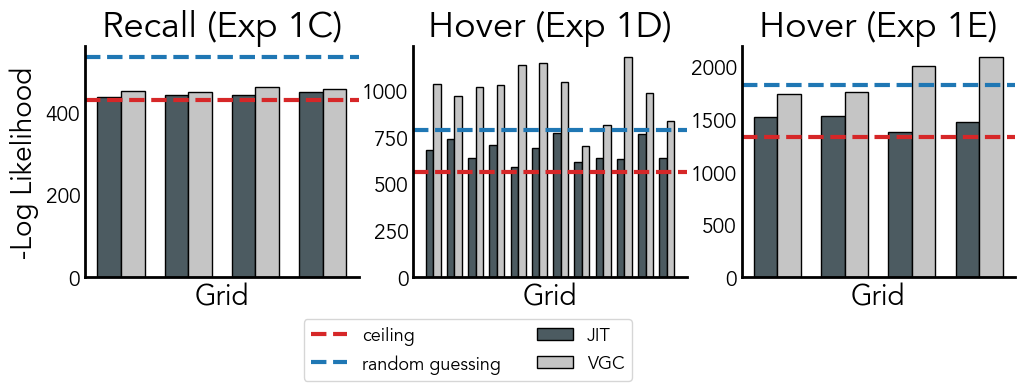

In [ ]:
_dvs = {
    dv: data
    for dv, data in dvs.items()
    if dv in ["critical_memory", "initial_hover", "critical_hover"]
    # if dv in [ "critical_hover"]
}
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for i, dv in enumerate(_dvs):
    group = likelihoods.query("dv == @dv")
    group = group.assign(ll = -group.loglik * group.n)
    plt.sca(axes[i])
    width = 0.35
    group1 = group.query("type == 'ReSiPe'")
    plt.bar(
        data=group1.groupby("grid", as_index=False).ll.sum(),
        x="grid",
        height="ll",
        width=width,
        color="#4C5B61",
        label="JIT",
        ec="k",
        lw=1
    )
    plt.xticks([], [])

    group2 = group.query("type == 'vgc'")
    # group2 = group2.assign(ll = group2.loglik * group2.n)
    plt.bar(
        data=group2.assign(grid=group2.grid + width).groupby("grid", as_index=False).ll.sum(),
        x="grid",
        height="ll",
        width=width,
        color="#C5C5C5",
        label="VGC",
        ec="k",
        lw=1
    )
    plt.xlabel("Grid")
    if i == 0:
        plt.ylabel("-Log Likelihood")

titles = {
    "critical_memory": "Recall (Exp 1C)",
    "initial_hover": "Hover (Exp 1D)",
    "critical_hover": "Hover (Exp 1E)",
}
for ax, dv in zip(axes, _dvs):
    # ceiling = -likelihoods.query("dv == @dv").entropy.sum()
    # floor = -likelihoods.query("dv == @dv").random.sum()
    # ceiling = -likelihoods.query("dv == @dv & type == 'ReSiPe'").groupby("grid").entropy.sum()
    ceiling = -likelihoods.query("dv == @dv & type == 'ReSiPe'").assign(tmp = lambda x: x.entropy * x.n).groupby("grid").tmp.sum()
    floor = -likelihoods.query("dv == @dv & type == 'ReSiPe'").assign(tmp = lambda x: x.random * x.n).groupby("grid").tmp.sum()
    print(ceiling)
    ax.axhline(ceiling.min(), 0, 100, color="tab:red", lw=3, ls="--", label="ceiling")
    ax.axhline(floor.mean(), 0, 100, color="tab:blue", lw=3, ls="--", label="random guessing")
    ax.set_title(titles[dv])

plt.legend(ncols=2, loc=(-1.6, -0.45), fontsize=13)
plt.savefig("../figures/navigation_likelihood.pdf", bbox_inches="tight")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


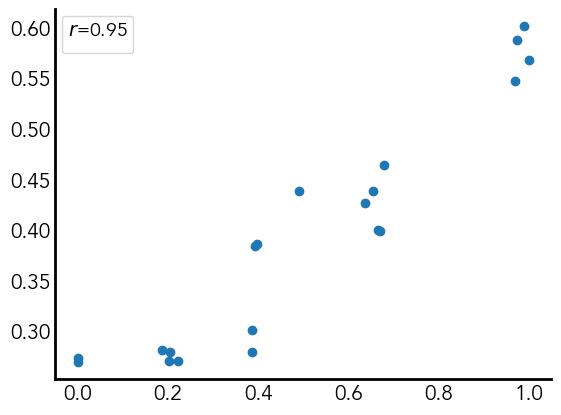

In [13]:
tmp = pd.merge(jit_predictions, vgc_predictions, on=["grid", "probeobs", "dv"], suffixes=("_jit", "_vgc"))
tmp = tmp.loc[tmp.dv == "critical_memory"]
plt.plot(tmp.prob, tmp.dynamic_vgc, "o")
plt.legend(title=f"$r$={tmp.prob.corr(tmp.dynamic_vgc):.2f}")